# **Projeto Final: Dataset "House Prices" - Predição de Preços e Clusterização dos Imóveis**

## Introdução ao Problema

O objetivo deste notebook é estimar o valor de um imóvel com base em dezenas de fatores que o influenciam, fatores esses trazidos pelo [dataset "House Prices"](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview), fornecido na plataforma Kaggle, que contém 79 dessas características explicativas, estruradas em diversos tipos de dados.

Além do objetivo preditivo, será feita uma análise de semelhança entre os imóveis presentes no conjunto de dados, na tentativa de reconhecer e descobrir padrões presentes por meio da clusterização.

### **Aplicação de Machine Learning**

-   **Aprendizado Supervisionado:** Predição e comparação do valor final do imóvel com relação a variável target 'SalePrice'.
-   **Aprendizado Não Supervisionado:** Segmentação de perfis dos imóveis a partir do algoritmo KMeans.

## Estrutura e Divisão do Dataset

* **train.csv (Conjunto de Treinamento):** Subconjunto de dados que contém as features e o target ('SalePrice'). Utilizado para treinamento do modelo supervisionado e construção dos clusters não supervisionados.
* **test.csv (Conjunto de Teste):** Subconjunto de dados contendo apenas as features, sem o target. Utilizado para gerar as previsões finais e avaliar a eficiência da predição.
* **data_description.txt (Dicionário de Dados):** Documentação detalhada especificando o conjunto de dados e o significado de cada uma das 79 colunas.
* **sample_submission.csv (Submissão de Benchmark):** Um exemplo que demostra o formato exato que o Kaggle exige para receber previsões. 

## Sumário

1. Importação de Bibliotecas
2. Carregamento e Inspeção dos Dados
3. Visualização Gráfica dos Dados
4. Análise de Qualidade dos Dados
5. Tratamento de Nulos
6. Tratamento de Outliers
7. Encoding de Variáveis Categóricas
8. Separação de Features e Target
9. Split de Treino e Teste
10. Modelo Supervisionado de Regressão Linear
11. Modelo de Ensemble 1- Random Forest
12. Modelo de Ensemble 2- Gradient Boost
13. Otimização de Hiperparâmetros
14. Avaliação dos modelos Supervisionados
15. Clusterização (KMeans)
16. Conclusão

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento e Inspeção dos Dados

In [2]:
# Carregamento dos dados
df_teste = pd.read_csv('data/train.csv')

In [3]:
# Shape do DataFrame gerado
print('Número de linhas e colunas: ')
print(df_teste.shape)

Número de linhas e colunas: 
(1460, 81)


In [4]:
# Primeiras 5 linhas do dataset
df_teste.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Visualização dos tipos de dados presentes no dataset
df_teste.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
# Medidas descritiva das variáveis numéricas
df_teste.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
# Nomes das 81 colunas presentes no DF
df_teste.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 3. Visualização Gráfica dos Dados

### **Histograma de SalePrice**

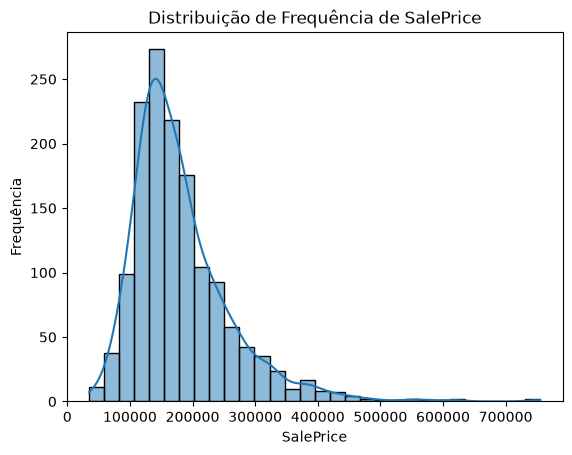

In [8]:
sns.histplot(df_teste['SalePrice'], kde=True, bins=30)
plt.title("Distribuição de Frequência de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequência")
plt.show()

A distribuição é assimétrica à direita, com pico entre 100k e 200k. Existem vendas bem acima disso, chegando perto de 700k, o que puxa a cauda do gráfico.

### **Boxplot de SalePrice**

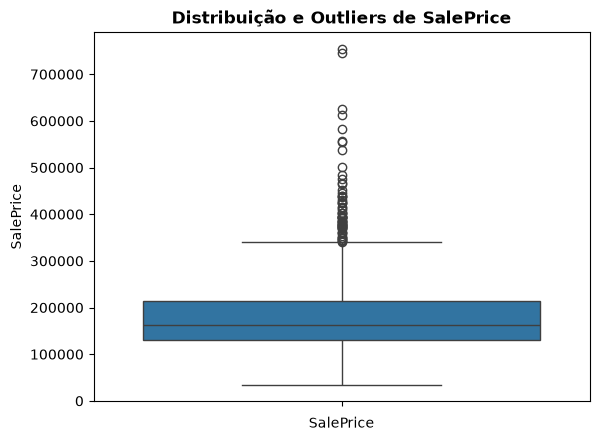

In [9]:
sns.boxplot(df_teste['SalePrice'])
plt.title("Distribuição e Outliers de SalePrice", fontsize=12, fontweight='bold')
plt.xlabel("SalePrice")
plt.show()

Confirma a assimetria vista no histograma. Tem bastante outlier acima do bigode superior, mas optei por não remover esses casos, já que são só imóveis caros de verdade, não erro de dado.

### **Gráfico de Dispersão (Scatter Plot) com reta:** Cruza a área útil do imóvel (GrLivArea) com o target (SalePrice). Revela visualmente a relação direta e a presença de outliers.

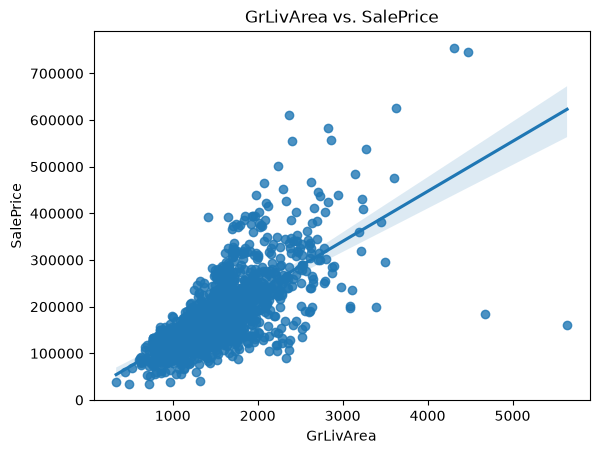

In [10]:
sns.regplot(x='GrLivArea', y='SalePrice', data=df_teste)
plt.title("GrLivArea vs. SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

Relação bem forte entre área e preço. Já dá pra notar os dois pontos fora da curva no canto inferior direito, que serão tratados como outliers na seção 6.


### **Distribuição dos Preços por bairro (Boxplot):** Exibe a variação de preços nos 10 bairros (Neighborhood) mais frequentes do conjunto.

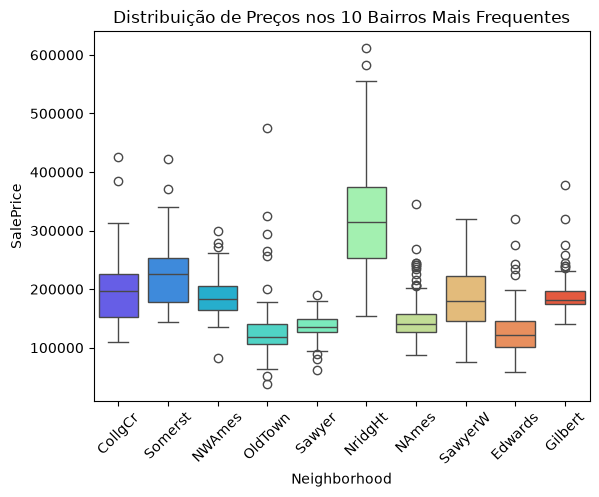

In [11]:
top_bairros = df_teste['Neighborhood'].value_counts().head(10).index
df_bairros = df_teste[df_teste['Neighborhood'].isin(top_bairros)]

sns.boxplot(x='Neighborhood', y='SalePrice', data=df_bairros, palette='rainbow',hue='Neighborhood')
plt.title("Distribuição de Preços nos 10 Bairros Mais Frequentes")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45)
plt.show()

NridgHt se destaca com os preços mais altos e maior variação. OldTown e Edwards ficam nas medianas mais baixas. Localização parece pesar bastante no preço final.

### **Heatmap entre as variáveis numéricas para análise de correlação**

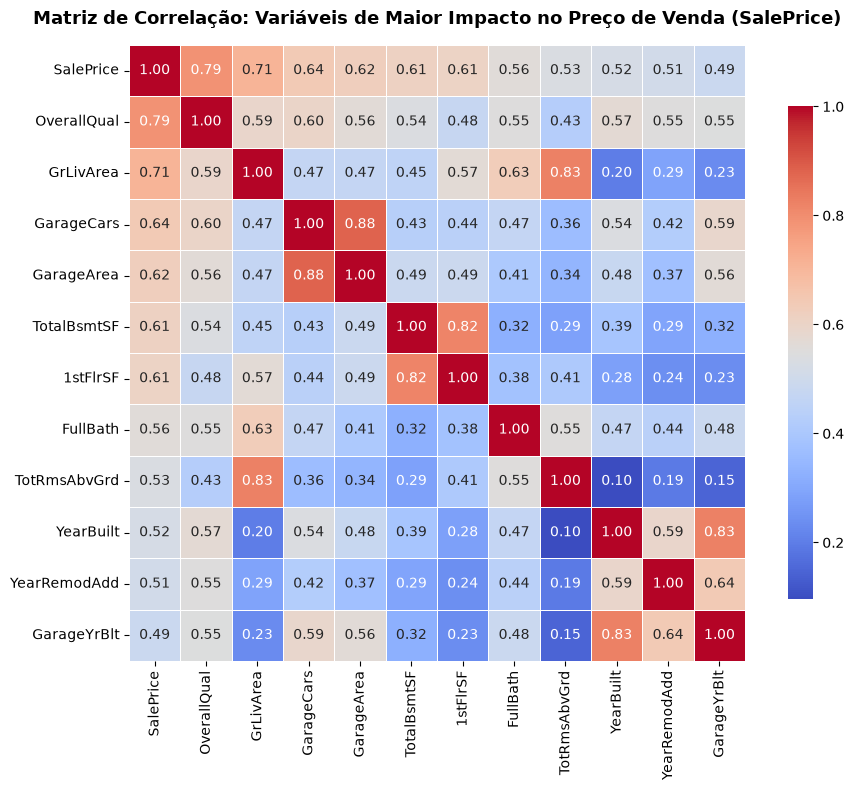

In [12]:
# Isolando apenas as colunas numéricas de df_teste
df_num = df_teste.select_dtypes(include=[np.number])

# Calculando a matriz de correlação de Pearson
matriz_corr = df_num.corr()

# Filtrando as 12 colunas mais correlacionadas com a target 'SalePrice'
top_corr_features = matriz_corr['SalePrice'].sort_values(ascending=False).head(12).index
matriz_top_corr = df_teste[top_corr_features].corr()

# Plotando o Heatmap altamente legível e estilizado
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_top_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlação: Variáveis de Maior Impacto no Preço de Venda (SalePrice)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

OverallQual (0.79) e GrLivArea (0.71) são as variáveis mais correlacionadas com SalePrice. Também dá pra ver pares bem correlacionados entre si, como GarageCars e GarageArea (0.88).

## 4. Análise de Qualidade dos Dados

In [13]:
# Exibindo a ausência de valores juntamente com a porcentagem dessa ausência sobre seu total
valores_ausentes = pd.DataFrame({
    'Valores Ausentes' : df_teste.isnull().sum(),
    'Porcentagem (%)' : (df_teste.isnull().mean() * 100).round(2)
})

# Filtra apenas as colunas que possuem valores ausentes
valores_ausentes = valores_ausentes[valores_ausentes['Valores Ausentes'] > 0]

# Exibe o resultado ordenado de ausência de forma decrescente
print(valores_ausentes.sort_values(by='Porcentagem (%)', ascending=False))

              Valores Ausentes  Porcentagem (%)
PoolQC                    1453            99.52
MiscFeature               1406            96.30
Alley                     1369            93.77
Fence                     1179            80.75
MasVnrType                 872            59.73
FireplaceQu                690            47.26
LotFrontage                259            17.74
GarageType                  81             5.55
GarageYrBlt                 81             5.55
GarageFinish                81             5.55
GarageQual                  81             5.55
GarageCond                  81             5.55
BsmtFinType2                38             2.60
BsmtExposure                38             2.60
BsmtFinType1                37             2.53
BsmtCond                    37             2.53
BsmtQual                    37             2.53
MasVnrArea                   8             0.55
Electrical                   1             0.07


## 5. Tratamento de Nulos

A maior parte dos nulos do dataset não representa dados ausentes de verdade, pois a documentação **(data_description.txt)** explica que, para várias colunas, nulo significa que o imóvel simplesmente não possui aquele recurso, por exemplo: sem piscina, sem porão, sem garagem, etc. 

Por isso, vou fazer o tratamento dividido em grupos, de acordo com o que o valor nulo realmente significa.

### **5.1** - Colunas categóricas onde nulo significa que "não possui o recurso"

In [14]:
cols_sem_recurso = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                     'BsmtFinType2', 'MasVnrType']

df_teste[cols_sem_recurso] = df_teste[cols_sem_recurso].fillna('None')

### **5.2** - Colunas numéricas onde nulo também significa "não possui o recurso"

In [15]:
# GarageYrBlt: sem garagem = sem ano de construção da garagem
# MasVnrArea: sem revestimento = 0 metros quadrados
df_teste['GarageYrBlt'] = df_teste['GarageYrBlt'].fillna(0)
df_teste['MasVnrArea'] = df_teste['MasVnrArea'].fillna(0)

### **5.3** - LotFrontage: nulo real, imputado pela mediana do bairro

In [16]:
# A testada do lote (LotFrontage) tende a variar por região, então a imputação
# é feita usando a mediana de cada bairro (Neighborhood), em vez da mediana global.
df_teste['LotFrontage'] = df_teste.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

### **5.4** - Electrical: apenas 1 valor nulo, removendo a linha

In [17]:
df_teste = df_teste.dropna(subset=['Electrical'])

### **5.5** - Conferindo se ainda restam valores nulos

In [18]:
print('Total de valores nulos restantes:', df_teste.isnull().sum().sum())

Total de valores nulos restantes: 0


## 6. Tratamento de Outliers

No gráfico de dispersão de GrLivArea x SalePrice, é possível identificar 2 imóveis com área acima de 4000, mas preço de venda muito baixo. Esses pontos fogem da tendência geral dos dados e podem ser considerados outliers.

Vou fazer uma verificação adicional de outliers com mais 2 features, sendo essas as features **'TotalBsmtSF'**, que mede o tamanho do porão do imóvel, e **'GarageArea'**, que mede o tamanho da garagem.

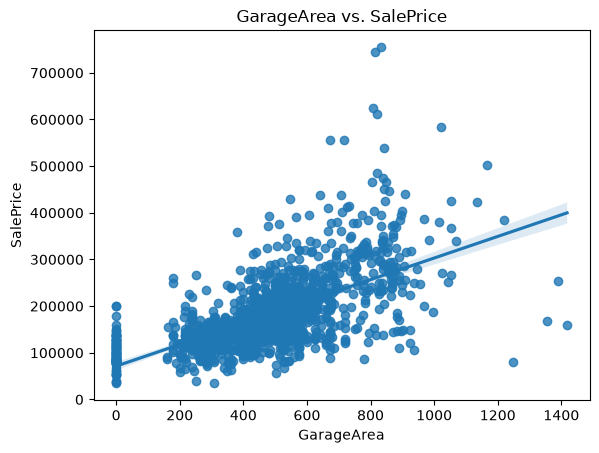

In [19]:
# Scatter Plot entre GarageArea e SalePrice
sns.regplot(x='GarageArea', y='SalePrice', data=df_teste)
plt.title("GarageArea vs. SalePrice")
plt.xlabel("GarageArea")
plt.ylabel("SalePrice")
plt.show()

Não apresenta outliers muito evidentes, os pontos seguem o padrão geral de dispersão.

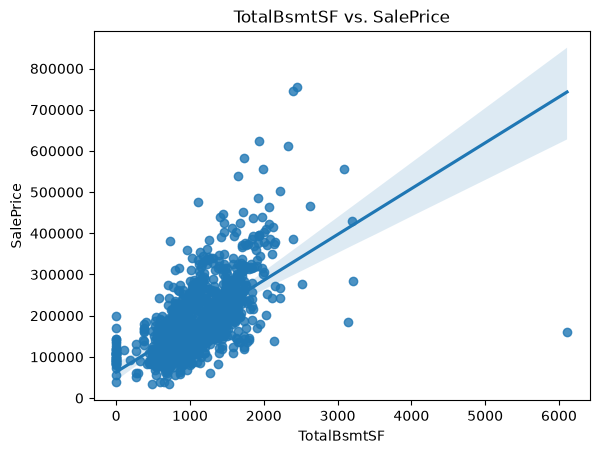

In [20]:
# Scatter plot entre 'TotalBsmtSF' e 'SalePrice'
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=df_teste)
plt.title("TotalBsmtSF vs. SalePrice")
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.show()

Já nesse caso, fica claro que existe mais um outlier, um único imóvel com um porão muito grande e um preço muito baixo.

Nesse caso, foram identificados 3 outliers ao todo nos 3 gráficos. Dessa forma, farei a remoção de todos eles, mas, primeiro, irei conferir se os outliers realmente diferem ou podem ser os mesmos, já que, analisando o Heatmap, as variáveis possuem um coeficiente de correlação moderado (0.45).

In [21]:
# Conferindo quais são outliers em cada feature antes de remover
outliers_grlivarea = df_teste[df_teste['GrLivArea'] > 4000]
outliers_totalbsmt = df_teste[df_teste['TotalBsmtSF'] > 4000]

print("Outliers em GrLivArea:")
print(outliers_grlivarea[['GrLivArea', 'TotalBsmtSF', 'SalePrice']])

print(
)

print("Outliers em TotalBsmtSF:")
print(outliers_totalbsmt[['GrLivArea', 'TotalBsmtSF', 'SalePrice']])


Outliers em GrLivArea:
      GrLivArea  TotalBsmtSF  SalePrice
523        4676         3138     184750
691        4316         2444     755000
1182       4476         2396     745000
1298       5642         6110     160000

Outliers em TotalBsmtSF:
      GrLivArea  TotalBsmtSF  SalePrice
1298       5642         6110     160000


Todos os outliers diferem entre si.

In [22]:
# Removendo todos os outliers identificados
df_teste = df_teste[(df_teste['GrLivArea'] < 4000) & (df_teste['TotalBsmtSF'] < 4000)]

Reexibindo ambos gráficos de dispersão após a remoção dos outliers:

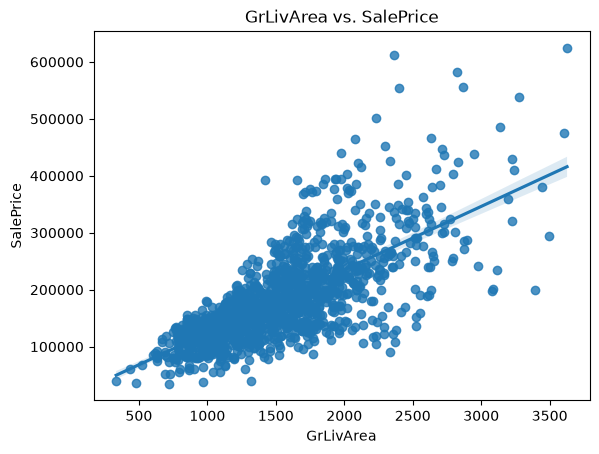

In [23]:
# Scatter Plot entre GrLivArea e SalePrice
sns.regplot(x='GrLivArea', y='SalePrice', data=df_teste)
plt.title("GrLivArea vs. SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

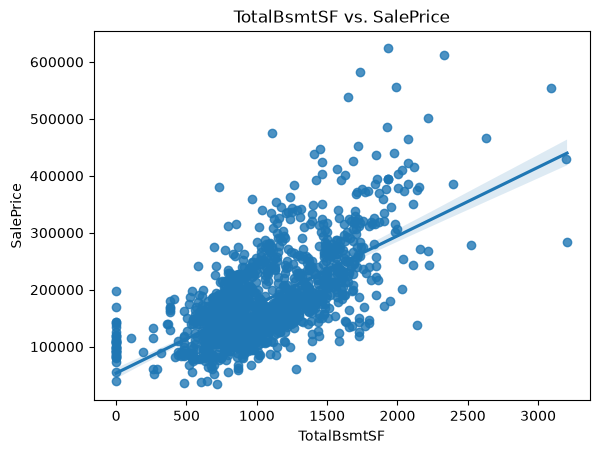

In [24]:
# Scatter plot entre 'TotalBsmtSF' e 'SalePrice'
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=df_teste)
plt.title("TotalBsmtSF vs. SalePrice")
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.show()

## 7. Encoding de Variáveis Categóricas

Usarei o OneHotEncoder do scikit-learn para transformar as colunas categóricas em colunas binárias de 0 ou 1.

A coluna 'Id' é removida por ser apenas um identificador, sem valor preditivo.

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
# Removendo a coluna 'Id'
df_teste = df_teste.drop(columns=['Id'])

Separando as colunas categóricas e numéricas, já que o OneHotEncoder deve ser aplicado apenas às categóricas.

In [27]:
# Conferindo quais colunas são categóricas antes do encoding
colunas_categoricas = df_teste.select_dtypes(include='str').columns
print(f'Total de colunas categóricas: {colunas_categoricas.shape}')
print(colunas_categoricas)

Total de colunas categóricas: (43,)
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


In [28]:
# Separando as colunas numéricas agora
colunas_numericas = df_teste.select_dtypes(exclude='object').columns
print(f'Total de colunas numéricas: {colunas_numericas.shape}')
print(colunas_numericas)

Total de colunas numéricas: (37,)
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')


Aplicando o OneHotEncoder nas 43 colunas categóricas e reunindo o resultado com as 37 colunas numéricas.

In [29]:
# Aplicando o OneHotEncoder nas colunas categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_teste[colunas_categoricas])

# Convertendo o resultado em DataFrame, com nomes de colunas legíveis
df_encoded_cat = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=df_teste.index
)

# Juntando as colunas numéricas originais com as colunas categóricas codificadas
df_encoded = pd.concat([df_teste[colunas_numericas], df_encoded_cat], axis=1)

# Conferindo o shape final
print('Shape antes do encoding:', df_teste.shape)
print('Shape depois do encoding:', df_encoded.shape)

Shape antes do encoding: (1455, 80)
Shape depois do encoding: (1455, 259)


## 8. Separação de Features e Target

Separando as features (X) da variável alvo (y = 'SalePrice'), já a partir do dataset codificado (df_encoded), que contém tanto as colunas numéricas originais quanto as colunas categóricas transformadas pelo OneHotEncoder.

In [30]:
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

# Conferindo as dimensões finais
print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Shape de X: (1455, 258)
Shape de y: (1455,)


## 9. Split de Treino e Teste

Dividindo o conjunto em treino (80%) e teste (20%), para treinar o modelo em uma parte dos dados e avaliar sua capacidade de generalização na outra.

In [31]:
# Importando a biblioteca para divisão do conjunto
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

## 10. Modelo Supervisionado de Regressão Linear

Modelo utilizado para prever o valor de venda 'SalePrice' dos imóveis a partir das demais features.

**Métricas de avaliação:**
- **R2:** mede a proporção da variação de SalePrice que o modelo consegue explicar (quanto mais próximo de 1 melhor).
- **MAE:** mede o erro médio absoluto das previsões, na mesma unidade do preço (dólares), indicando o quanto o modelo erra na prática.

In [32]:
# Importando o modelo de regressão, juntamente com as métricas avaliativas
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Atribuindo o modelo e treinando o mesmo
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](258,)","[ -40.38, 45.95, 0.81,...,-4972.08, 4620.37,-4721.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](258,)","['MSSubClass','LotFrontage','LotArea',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.571e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,258
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(237)


In [33]:
# Valores previstos pelo modelo
y_predict = modelo_regressao.predict(X_test)

# Cálculo do coeficiente de proximidade entre a saída do modelo com a saída real
r2 = r2_score(y_test, y_predict)

# Cálculo do Mean Absolute Error
mae = mean_absolute_error(y_test, y_predict)

# Precisão de 2 casas decimais para ambas as métricas
print(f'R2: {r2:.2f}') 
print(f'MAE: {mae:.2f}')

R2: 0.92
MAE: 16994.09


### Comparação gráfica: Previsão x Realidade

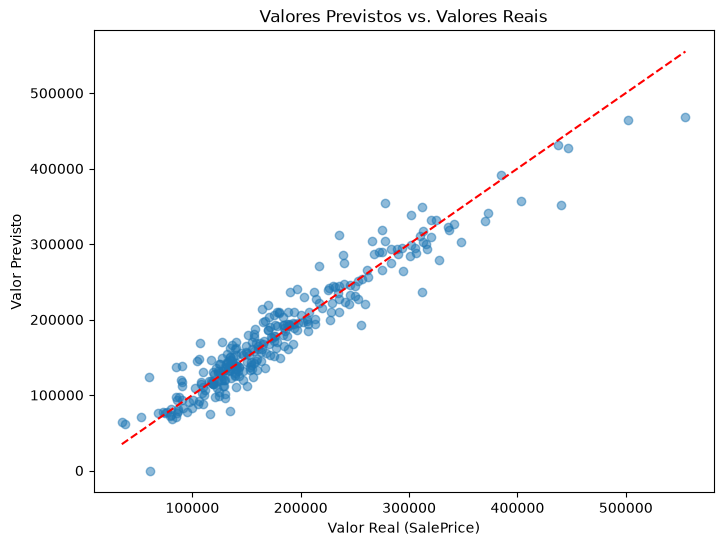

In [34]:
# Visualizando a relação entre os valores previstos e os valores reais, para identificar
# visualmente onde o modelo mais erra.

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valor Real (SalePrice)')
plt.ylabel('Valor Previsto')
plt.title('Valores Previstos vs. Valores Reais')
plt.show()

O gráfico confirma visualmente o R2: a maioria dos pontos está bem próxima da linha de previsão.

### Avaliação dos resultados

R2 de 0.92 — o modelo explica cerca de 92% da variação nos preços, o que achei um resultado bem
sólido considerando que a separação das features foi simples, sem nenhum tratamento especial.

In [35]:
# Mostrando o preço médio de uma venda no dataset 
df_teste['SalePrice'].mean()

np.float64(180159.92852233676)

Tem-se que no dataset, o preço médio de uma venda é de aproximadamente 180.000, o que gera um erro de menos de 10% da média. Isso pode representar uma quantia significativa e impactar fortemente na tomada de decisão final. 

## 11. Modelo de Ensemble 1- Random Forest

Diferente da Regressão Linear, que assume uma relação linear entre as features e o preço, o Random Forest combina várias árvores de decisão treinadas em subconjuntos aleatórios dos dados e das features. A previsão final é a média das previsões de todas as árvores.

Isso traz duas vantagens em relação ao modelo anterior: captura relações não-lineares entre as variáveis, e é naturalmente mais robusto à multicolinearidade discutida na seção 10, já que cada árvore escolhe apenas um subconjunto de features a cada divisão.

In [36]:
# Importando o modelo de ensemble
from sklearn.ensemble import RandomForestRegressor

# Atribuindo o modelo e treinando o mesmo
modelo_rf = RandomForestRegressor(random_state=51)
modelo_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",51
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [37]:
# Valores previstos pelo modelo
y_predict_rf = modelo_rf.predict(X_test)

# Cálculo do coeficiente de proximidade entre a saída do modelo com a saída real
r2_rf = r2_score(y_test, y_predict_rf)

# Cálculo do Mean Absolute Error
mae_rf = mean_absolute_error(y_test, y_predict_rf)

print(f'R2: {r2_rf:.2f}')
print(f'MAE: {mae_rf:.2f}')

R2: 0.86
MAE: 19149.98


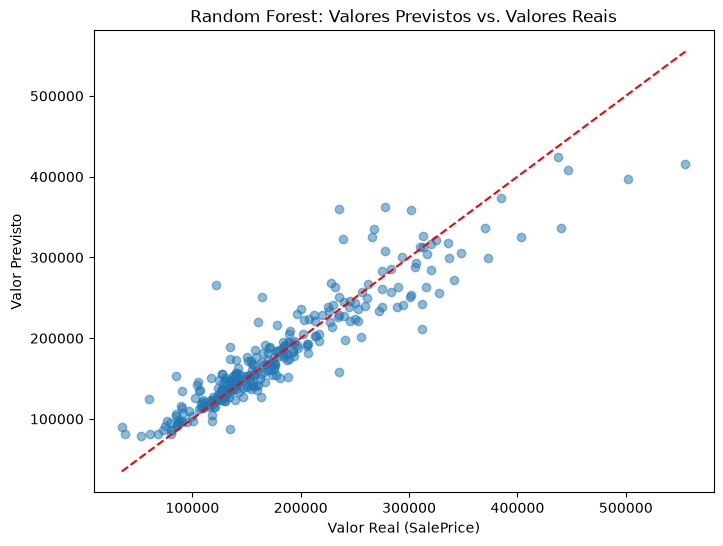

In [38]:
# Visualizando a relação entre os valores previstos e os valores reais, para identificar
# visualmente onde o modelo mais erra.

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valor Real (SalePrice)')
plt.ylabel('Valor Previsto')
plt.title('Random Forest: Valores Previstos vs. Valores Reais')
plt.show()

Dá pra ver mais dispersão em relação à linha ideal aqui, principalmente nos imóveis mais caros —
condiz com o R2 mais baixo desse modelo.

### Avaliação dos resultados

R2 de 0.86 e MAE de 19,149.98 — abaixo da Regressão Linear. Não esperava que a diferença fosse tão grande. Pelo visto, a relação entre as features e o preço já era forte o suficiente de forma linear (`OverallQual` e `GrLivArea` já tinham correlação alta lá no heatmap), então o Random Forest não teve muito "não-linearidade" pra explorar e ainda saiu perdendo pro baseline mais simples.

## 12. Modelo de Ensemble 2- Gradient Boosting

### Gradient Boosting

Diferente do Random Forest, que treina as árvores de forma independente e depois tira a média
das previsões, o Gradient Boosting treina as árvores de forma **sequencial**: cada nova árvore
é construída para corrigir os erros (resíduos) deixados pela árvore anterior.

Essa abordagem costuma ter maior poder preditivo do que o Random Forest, mas também é mais
sensível a hiperparâmetros mal ajustados (como número de árvores e taxa de aprendizado) — o que
reforça a importância da etapa de otimização de hiperparâmetros logo em seguida.

In [39]:
# Importando o modelo de Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

# Atribuindo o modelo e treinando o mesmo
modelo_gb = GradientBoostingRegressor(random_state=51)
modelo_gb.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",51
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [40]:
# Valores previstos pelo modelo
y_predict_gb = modelo_gb.predict(X_test)

# Cálculo do coeficiente de proximidade entre a saída do modelo com a saída real
r2_gb = r2_score(y_test, y_predict_gb)

# Cálculo do Mean Absolute Error
mae_gb = mean_absolute_error(y_test, y_predict_gb)

print(f'R2: {r2_gb:.2f}')
print(f'MAE: {mae_gb:.2f}')

R2: 0.91
MAE: 16305.49


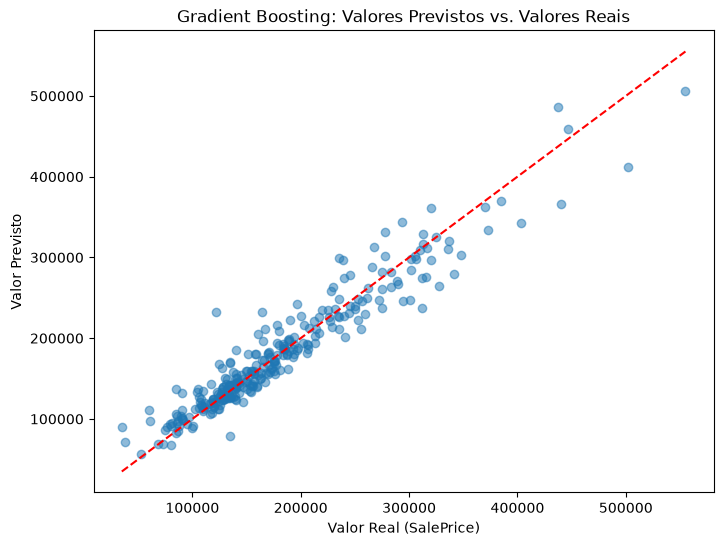

In [41]:
# Visualizando a relação entre os valores previstos e os valores reais, para identificar
# visualmente onde o modelo mais erra.

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valor Real (SalePrice)')
plt.ylabel('Valor Previsto')
plt.title('Gradient Boosting: Valores Previstos vs. Valores Reais')
plt.show()

Os pontos ficam mais próximos da linha do que no Random Forest, o que já era esperado pelo R2
mais alto.

### Avaliação dos resultados

Aqui melhorou bastante em relação ao Random Forest: R2 de 0.91, MAE de 16,305.49 — inclusive o
menor MAE entre os três modelos até agora, mesmo com R2 um pouco abaixo da Regressão Linear. Faz
sentido, já que o treino sequencial do Gradient Boosting corrige os erros de cada árvore
anterior, então ele lida melhor com a bagunça que o encoding gerou do que o Random Forest.

## 13. Otimização de Hiperparâmetros

### GridSearchCV

Como o Gradient Boosting obteve o melhor MAE entre os modelos de ensemble, ele foi escolhido
para a etapa de otimização de hiperparâmetros. Usarei o GridSearchCV, que testa
exaustivamente todas as combinações de uma grade de parâmetros pré-definida, usando validação
cruzada (cv=5) para escolher a combinação com melhor desempenho médio, evitando que a escolha
dependa de um único split de treino/teste.

Os parâmetros ajustados serão:
- **n_estimators:** número de árvores treinadas sequencialmente.
- **learning_rate:** o quanto cada nova árvore corrige o erro da anterior (taxa de aprendizado).
- **max_depth:** profundidade máxima de cada árvore individual.

In [42]:
# Importando a ferramenta de busca de hiperparâmetros
from sklearn.model_selection import GridSearchCV

# Definindo a grade de parâmetros a serem testados
parametros = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

# Configurando a busca: testa todas as combinações com validação cruzada de 5 folds,
# usando o R2 como métrica de comparação entre as combinações
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=51),
    param_grid=parametros,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Rodando a busca
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=51)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [43]:
# Exibindo a melhor combinação de hiperparâmetros encontrada
print('Melhores hiperparâmetros:', grid_search.best_params_)

# Atribuindo o melhor modelo encontrado pela busca
modelo_gb_otimizado = grid_search.best_estimator_

# Valores previstos pelo modelo otimizado
y_predict_gb_otimizado = modelo_gb_otimizado.predict(X_test)

# Cálculo do coeficiente de proximidade entre a saída do modelo com a saída real
r2_gb_otimizado = r2_score(y_test, y_predict_gb_otimizado)

# Cálculo do Mean Absolute Error
mae_gb_otimizado = mean_absolute_error(y_test, y_predict_gb_otimizado)

print(f'R2: {r2_gb_otimizado:.2f}')
print(f'MAE: {mae_gb_otimizado:.2f}')

Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
R2: 0.91
MAE: 16353.82


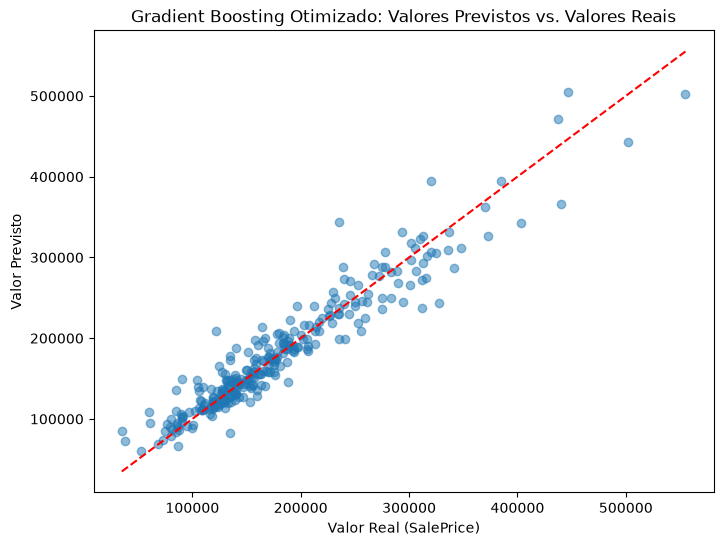

In [44]:
# Comparando visualmente os valores previstos com os valores reais
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict_gb_otimizado, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valor Real (SalePrice)')
plt.ylabel('Valor Previsto')
plt.title('Gradient Boosting Otimizado: Valores Previstos vs. Valores Reais')
plt.show()

### Avaliação dos resultados

A otimização encontrou como melhor combinação `learning_rate=0.1`, `max_depth=2` e
`n_estimators=300`, resultando em **R2 de 0.91** e **MAE de 16,353.82** — praticamente
idêntico ao modelo com hiperparâmetros padrão (R2 0.91, MAE 16,305.49). O GridSearchCV não
trouxe ganho prático nesse caso, o que sugere que os parâmetros padrão do Gradient Boosting já
estavam bem ajustados para este dataset, e que a limitação de desempenho está mais relacionada à
representação dos dados (o encoding das variáveis categóricas) do que aos hiperparâmetros do
próprio algoritmo.

## 14. Comparação Final dos Modelos

Reunindo as métricas de todos os modelos treinados até aqui, para facilitar a comparação lado a
lado.

In [45]:
# Montando uma tabela comparativa com os resultados de todos os modelos treinados
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'Gradient Boosting', 'Gradient Boosting Otimizado'],
    'R2': [r2, r2_rf, r2_gb, r2_gb_otimizado],
    'MAE': [mae, mae_rf, mae_gb, mae_gb_otimizado]
})

# Ordenando pelo R2, do melhor para o pior
resultados.sort_values(by='R2', ascending=False)

,Modelo,R2,MAE
0,Regressão Linear,0.915518,16994.092187
2,Gradient Boosting,0.914164,16305.493202
3,Gradient Boosting Otimizado,0.913042,16353.824421
1,Random Forest,0.860360,19149.982234


### Avaliação final entre os modelos

A Regressão Linear se manteve como o modelo de melhor desempenho entre os quatro testados, com
R2 de 0.9155 e MAE de 16,994.09. Vale destacar, porém, que a diferença para o Gradient Boosting
(R2 0.9142, MAE 16,305.49) é mínima — o Gradient Boosting inclusive teve o menor MAE entre todos
os modelos, mesmo com R2 ligeiramente inferior. O Random Forest ficou visivelmente atrás dos
demais (R2 0.8604), e a otimização de hiperparâmetros do Gradient Boosting não trouxe ganho
prático sobre sua versão padrão (R2 0.9130, MAE 16,353.82).

Esse resultado reforça uma conclusão importante do projeto: modelo mais complexo não é sinônimo
de resultado melhor. Nesse caso específico, a relação entre as features mais importantes
(`OverallQual`, `GrLivArea`) e o preço já era predominantemente linear, e o encoding escolhido
(OneHotEncoder aplicado uniformemente a todas as colunas categóricas, inclusive as ordinais)
favoreceu estruturalmente o modelo linear em detrimento dos modelos baseados em árvore.

### Escolha de modelo para Streamlit

Com todos os modelos testados e avaliados, escolherei um deles para ser a base da aplicação web usando Streamlit. Por ser o modelo que desempenhou melhor, vou utilizar a Regressão Linear como base.

In [46]:
import joblib 
joblib.dump(modelo_regressao, 'modelo_regressao_linear.joblib')

['modelo_regressao_linear.joblib']

## 16. Clusterização (KMeans)

Partindo para um problema de aprendizado não supervisionado, a clusterização, será usado um subconjunto de features numéricas, que ajudam a descrever o "perfil" de um imóvel, sendo estas: 
-   **Área construída** ('GrLivArea')
-   **Qualidade geral** ('OverallQual') 
-   **Área do porão** ('TotalBsmtSF') 
-   **Capacidade da garagem** ('GarageCars') 
-   **Número de banheiros completos** ('FullBath') 
-   **Número de quartos** ('BedroomAbvGr')
-   **Ano de construção** ('YearBuilt)

Diferente da regressão, não é necessário usar todas as 259 colunas do dataset codificado — o objetivo aqui é encontrar grupos de imóveis com características físicas semelhantes.

### Seleção de Features

In [47]:
# Criando a lista de features
features_cluster = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars',
                     'FullBath', 'BedroomAbvGr', 'YearBuilt']

# Criação de um novo DF contendo somente as features selecionadas
X_cluster = df_teste[features_cluster].copy()

# Primeiras 5 linhas do DF de cluster
X_cluster.head()

,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,FullBath,BedroomAbvGr,YearBuilt
0,1710,7,856,2,2,3,2003
1,1262,6,1262,2,2,3,1976
2,1786,7,920,2,2,3,2001
3,1717,7,756,3,1,3,1915
4,2198,8,1145,3,2,4,2000


### Normalização das Features

O KMeans se baseia no cálculo de distâncias, então features em escalas muito diferentes como 'GrLivArea' em pés ao quadrado, variando na casa dos milhares, contra 'FullBath', que varia entre 0 e 4 distorceriam esse cálculo. Por isso é necessário o processo de normalização das features.

O processo de padronização transforma as variáveis para que:
-   A média de cada coluna seja 0
-   O desvio padrão de cada coluna seja 1.

In [48]:
# Importa a função que padroniza os dados
from sklearn.preprocessing import StandardScaler


Para cada valor de uma coluna, a função StandardScaler aplica a fórmula z = (x - u)/q, no qual:
-   x é o valor original
-   u é a média da coluna
-   q é o desvio padrão da coluna 

In [49]:
scaler = StandardScaler()

# Calcula a média e o desvio padrão de cada coluna do DF
# Depois, aplica a fórmula de transformação em cada valor.
X_cluster_normalizado = scaler.fit_transform(X_cluster)

### Método do Cotovelo

Rodando o KMeans para diferentes quantidades de clusters (k), com objetivo de identificar o ponto onde o WCSS (soma das distâncias quadráticas dentro de cada cluster) para de cair de forma significativa — o "cotovelo" do gráfico.


In [50]:
# Importa o modelo KMeans
from sklearn.cluster import KMeans

wcss = []

# Repete o processo 10 vezes, criando um novo modelo a cada iteração
# que configura o número de clusters no valor igual ao da variável n.
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=51, n_init=10)
    kmeans.fit(X_cluster_normalizado)
    wcss.append(kmeans.inertia_)

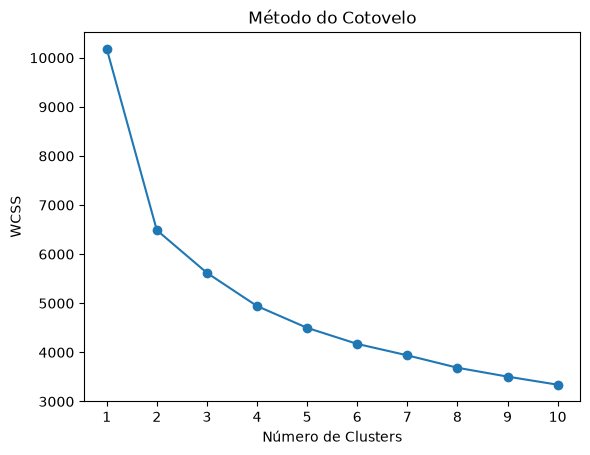

In [51]:
# Exibição no gráfico para identificar visualmente o "cotovelo"
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xticks(range(1, 11))
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

### Escolha do número de clusters

Analisando o gráfico, a curva apresenta uma queda acentuada até k=3, e a partir daí a redução do WCSS passa a ser mais suave, tanto k=3 quanto k=4 aparentam ser boas escolhas, já que os dois estão na região do cotovelo. 

Optei por seguir com k=3, por representar o ponto onde aparenta ser a mudança mais evidente de comportamento.

### Execução do Algoritmo e Visualização dos Clusters

Agora é executado o KMeans com k=3 sobre os dados normalizados, e guardo os clusters em uma cópia do DF original para visualização, para manten X_cluster_normalizado limpo, sem a coluna de cluster, para uso posterior na métrica de avaliação.


In [52]:
# Rodando o KMeans com k = 3
modelo_kmeans = KMeans(n_clusters=3, random_state=51, n_init=10)
y_kmeans = modelo_kmeans.fit_predict(X_cluster_normalizado)

# Centroides para visualização no gráfico
# Revertendo os centroides do espaço normalizado para a escala original
centroides_original = scaler.inverse_transform(modelo_kmeans.cluster_centers_)
centroides = pd.DataFrame(centroides_original, columns=X_cluster.columns)

# Cópia com a coluna de clusters, para fazer o gráfico
X_cluster_total = X_cluster.copy()
X_cluster_total['clusters'] = y_kmeans

Visualizando os clusters em dois pares de features: área construída x qualidade geral (GrLivArea x OverallQual) e área do porão x capacidade da garagem (TotalBsmtSF x GarageCars).

In [53]:
def scatterplot(x,y,data,cent):
  # Representando gráficamente os grupos
  sns.scatterplot(x=x,y=y,data=data,hue='clusters'
                ,palette='tab10')

  # Representando os centroides - X em vermelho no gráfico
  sns.scatterplot(x=x,y=y,data=cent
                  ,c='red',marker='X', s=100)

  plt.title(f'KMeans sobre {x} e {y}')

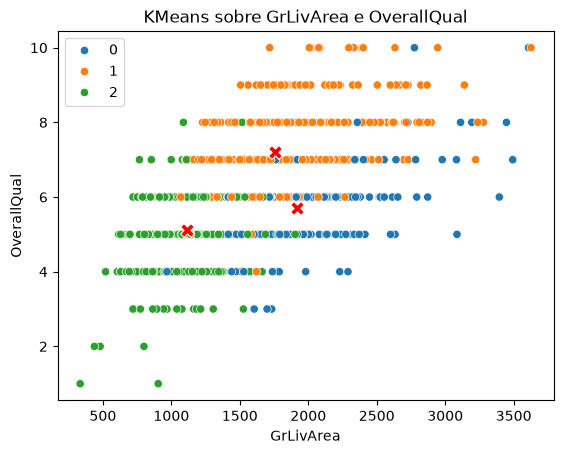

In [54]:
scatterplot('GrLivArea', 'OverallQual',X_cluster_total,centroides)

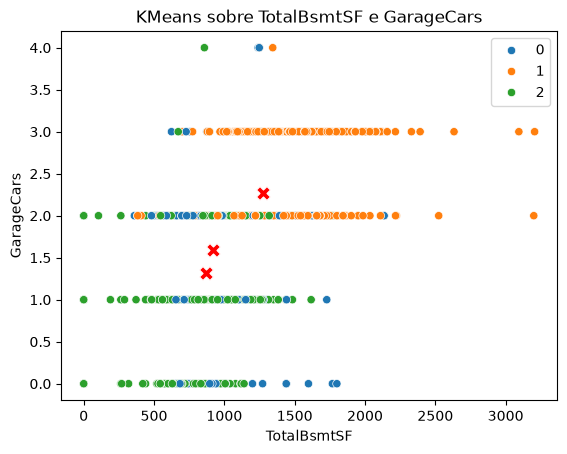

In [55]:
scatterplot('TotalBsmtSF', 'GarageCars',X_cluster_total,centroides)

### Interpretação dos Clusters

Os três clusters formados parecem agrupar os imóveis principalmente pelo seu tamanho e sua qualidade: o cluster 2 concentra os imóveis menores e de qualidade mais baixa, o cluster 1 concentra os de qualidade mais alta (independente do tamanho), e o cluster 0 fica numa faixa central.

Isso sugere que o KMeans capturou um padrão coerente de "perfil" do imóvel a partir das features escolhidas.

### Silhouette Score

Avaliando a qualidade da separação entre os clusters. Importante usar X_cluster_normalizado (sem a coluna de cluster) para não "viciar" o cálculo.

In [56]:
# Importando o método que calcula o score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_cluster_normalizado, y_kmeans)
print(f'Silhouette Score: {score:.2f}')

Silhouette Score: 0.31


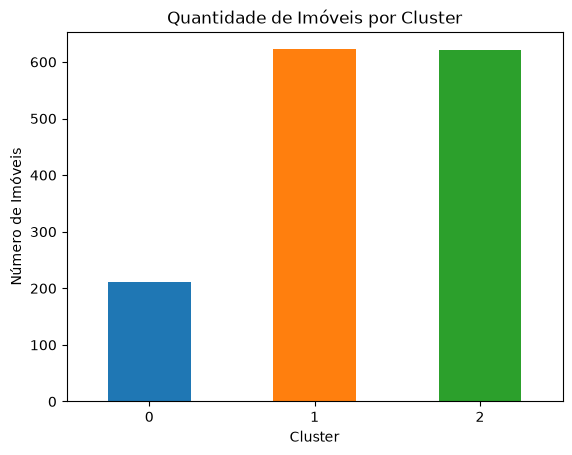

In [57]:
# Mostrando a quantidade de imóveis por cluster identificado

X_cluster_total['clusters'].value_counts().sort_index().plot(kind='bar', color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Quantidade de Imóveis por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de Imóveis')
plt.xticks(rotation=0)
plt.show()

### Avaliação do Silhouette Score

O modelo obteve um **Silhouette Score de 0.31**, que indica uma estrutura de agrupamento média. 

## 16. Conclusão

Esse projeto cobriu praticamente todo o fluxo de um problema real de dados: inspeção inicial,
tratamento de qualidade, comparação entre vários modelos supervisionados e, por fim, a
segmentação não supervisionada dos imóveis.

### Aprendizado Supervisionado

Testei quatro modelos pra prever o `SalePrice`: Regressão Linear, Random Forest, Gradient
Boosting e Gradient Boosting com hiperparâmetros otimizados. A Regressão Linear saiu na frente (R2 0.9155, MAE 16,994.09), com o Gradient Boosting padrão logo atrás (R2 0.9142, MAE 16,305.49). O Random Forest ficou visivelmente pra trás dos outros, e otimizar os hiperparâmetros do Gradient Boosting não trouxe ganho real. Depois da avaliação e comparação dos modelos, escolhi o de Regressão Linear para fazer as predições interativas com o Streamlit.

O que eu tiro disso: nem sempre o modelo mais sofisticado ganha. Aqui, a relação entre as
principais features e o preço já era bem linear, e o jeito como fiz o encoding (OneHot em tudo,
até nas colunas que tinham ordem, como `KitchenQual` e `ExterQual`) acabou favorecendo o modelo
linear sem eu ter planejado isso de propósito.

### Aprendizado Não Supervisionado

Agrupei os imóveis em 3 clusters usando `GrLivArea`, `OverallQual`, `TotalBsmtSF`, `GarageCars`,
`FullBath`, `BedroomAbvGr` e `YearBuilt`. Deu pra ver um padrão consistente de segmentação por
tamanho e qualidade, com Silhouette Score de 0.31 — separação fraca a moderada, o que faz sentido
já que imóveis não se encaixam em categorias tão rígidas quanto outros tipos de dado.

### Considerações finais

No fim, os dois lados do projeto cumpriram o que se propuseram: a parte supervisionada entregou
uma predição confiável de preço, e o KMeans ajudou a enxergar perfis de imóveis sem depender do
preço como referência. O maior aprendizado, olhando pra trás, foi perceber o quanto a escolha do
pré-processamento influencia qual modelo acaba "ganhando" — e que vale a pena questionar essa
escolha antes de assumir que o modelo mais complexo é o melhor caminho.